In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Libraries Install & Import


!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# Apna exact Drive path yahan daalo
BASE_PATH = '/content/drive/MyDrive/YOLOComparison'

models = ['yolov8', 'yolov9', 'yolov10']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Check karo sab folders hain ya nahi
for model in models:
    path = f"{BASE_PATH}/{model}"
    if os.path.exists(path):
        print(f"✅ {model} folder found")
    else:
        print(f"❌ {model} folder NOT found — path check karo!")

✅ yolov8 folder found
✅ yolov9 folder found
✅ yolov10 folder found


**Metrics Load karo (results.csv se)**

In [ ]:
all_metrics = {}

for model in models:
    csv_path = f"{BASE_PATH}/{model}/results.csv"
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        last = df.iloc[-1]
        all_metrics[model] = {
            'mAP50':          round(float(last['metrics/mAP50(B)']), 4),
            'mAP50_95':       round(float(last['metrics/mAP50-95(B)']), 4),
            'Precision':      round(float(last['metrics/precision(B)']), 4),
            'Recall':         round(float(last['metrics/recall(B)']), 4),
            'Train_Box_Loss': round(float(last['train/box_loss']), 4),
            'Val_Box_Loss':   round(float(last['val/box_loss']), 4),
            'Training_Time':  round(float(df['time'].iloc[-1]), 2),
        }
        all_metrics[model]['F1'] = round(
            2 * all_metrics[model]['Precision'] * all_metrics[model]['Recall'] /
            (all_metrics[model]['Precision'] + all_metrics[model]['Recall'] + 1e-8), 4
        )
        print(f"✅ {model} loaded")
    else:
        print(f"❌ {model} — results.csv nahi mila!")

metrics_df = pd.DataFrame(all_metrics).T
print("\n📊 METRICS TABLE:")
print(metrics_df.to_string())

✅ yolov8 loaded
✅ yolov9 loaded
✅ yolov10 loaded

📊 METRICS TABLE:
          mAP50  mAP50_95  Precision  Recall  Train_Box_Loss  Val_Box_Loss  Training_Time      F1
yolov8   0.7597    0.4390     0.7318  0.6814          1.0124        1.4182        4265.87  0.7057
yolov9   0.7683    0.4549     0.7770  0.6929          0.9895        1.4066       10817.40  0.7325
yolov10  0.7438    0.4372     0.7602  0.6480          1.1833        1.4769        9198.69  0.6996


** Bar Chart (mAP, F1, Precision, Recall)**

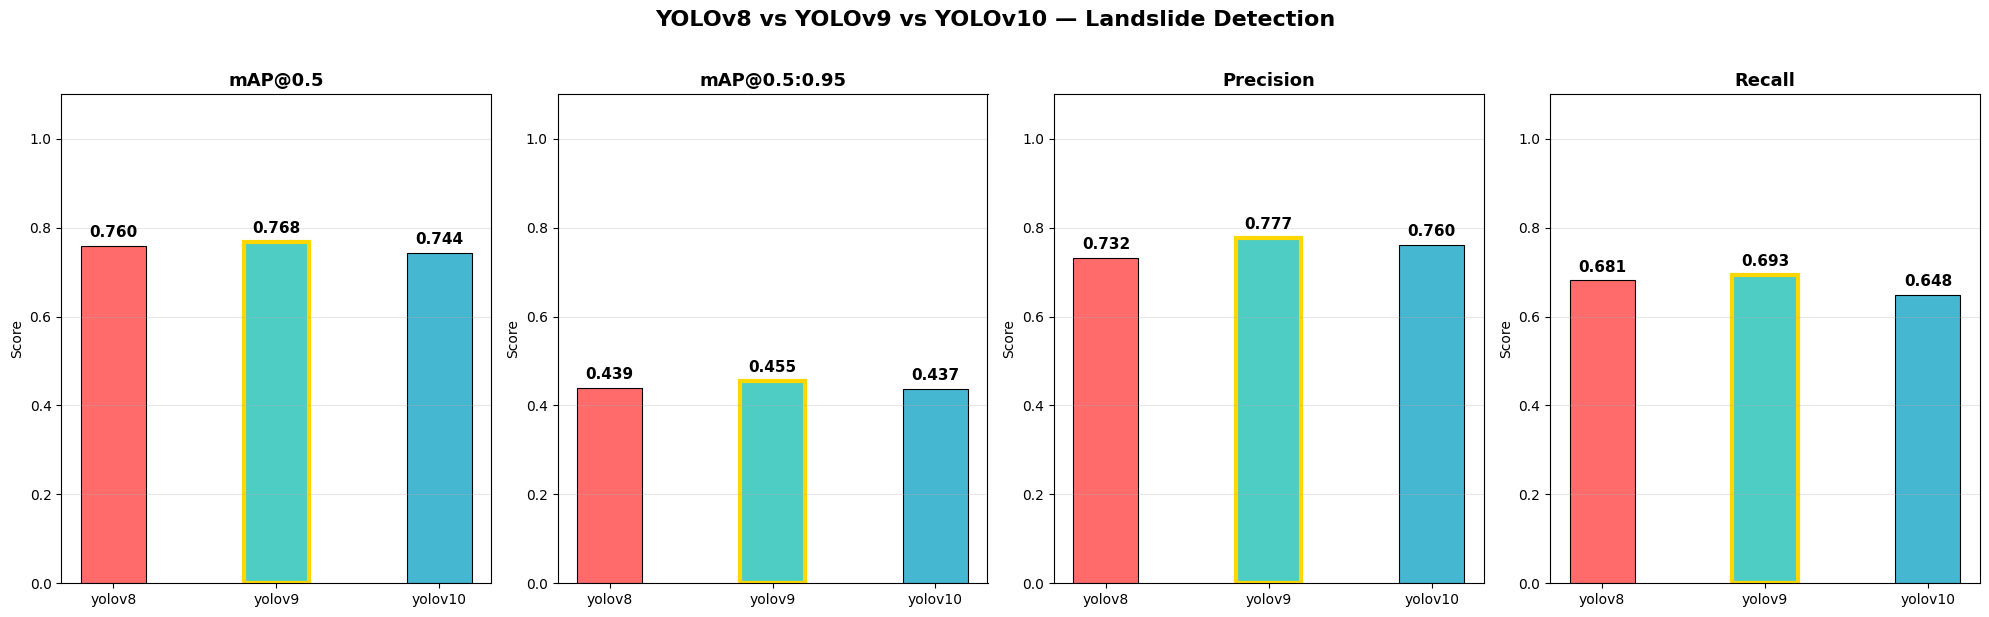

✅ Saved!


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('YOLOv8 vs YOLOv9 vs YOLOv10 — Landslide Detection',
             fontsize=16, fontweight='bold', y=1.02)

metric_list = [
    ('mAP50',    'mAP@0.5'),
    ('mAP50_95', 'mAP@0.5:0.95'),
    ('Precision','Precision'),
    ('Recall',   'Recall')
]

for ax, (metric, label) in zip(axes, metric_list):
    bars = ax.bar(models, metrics_df[metric], color=colors,
                  edgecolor='black', linewidth=0.8, width=0.4)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    best_idx = list(metrics_df[metric].values).index(metrics_df[metric].max())
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/1_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

**Training Loss Curves**

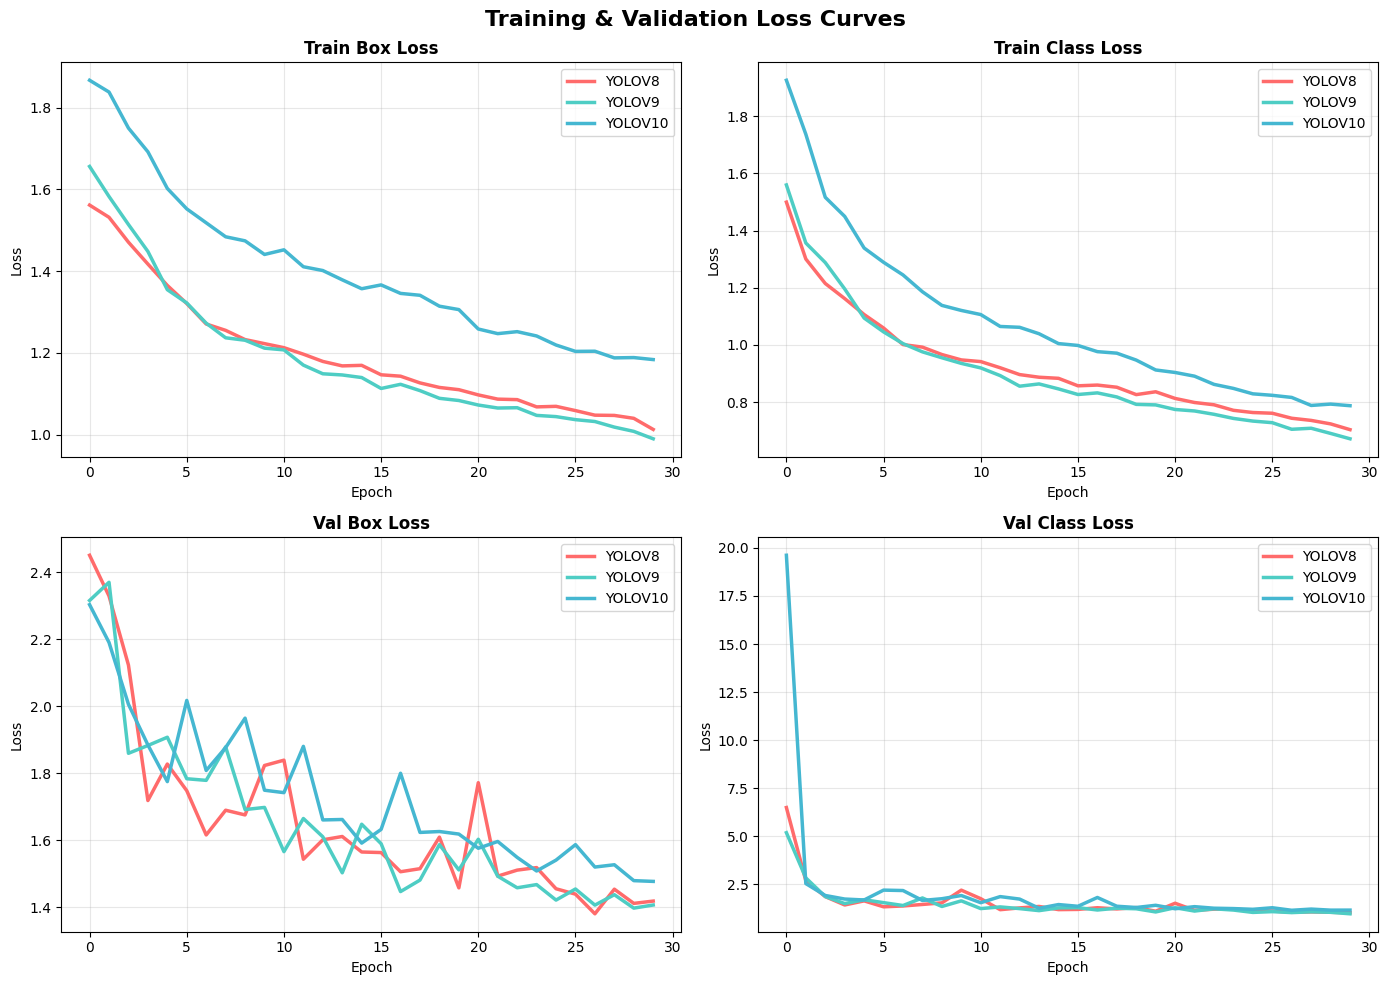

✅ Saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training & Validation Loss Curves', fontsize=16, fontweight='bold')

loss_info = [
    ('train/box_loss', 'Train Box Loss'),
    ('train/cls_loss', 'Train Class Loss'),
    ('val/box_loss',   'Val Box Loss'),
    ('val/cls_loss',   'Val Class Loss'),
]

for ax, (col, label) in zip(axes.flat, loss_info):
    for model, color in zip(models, colors):
        csv_path = f"{BASE_PATH}/{model}/results.csv"
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df.columns = df.columns.str.strip()
            if col in df.columns:
                ax.plot(df[col], label=model.upper(), color=color, linewidth=2.5)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/2_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

**Confusion Matrices Side by Side**

---



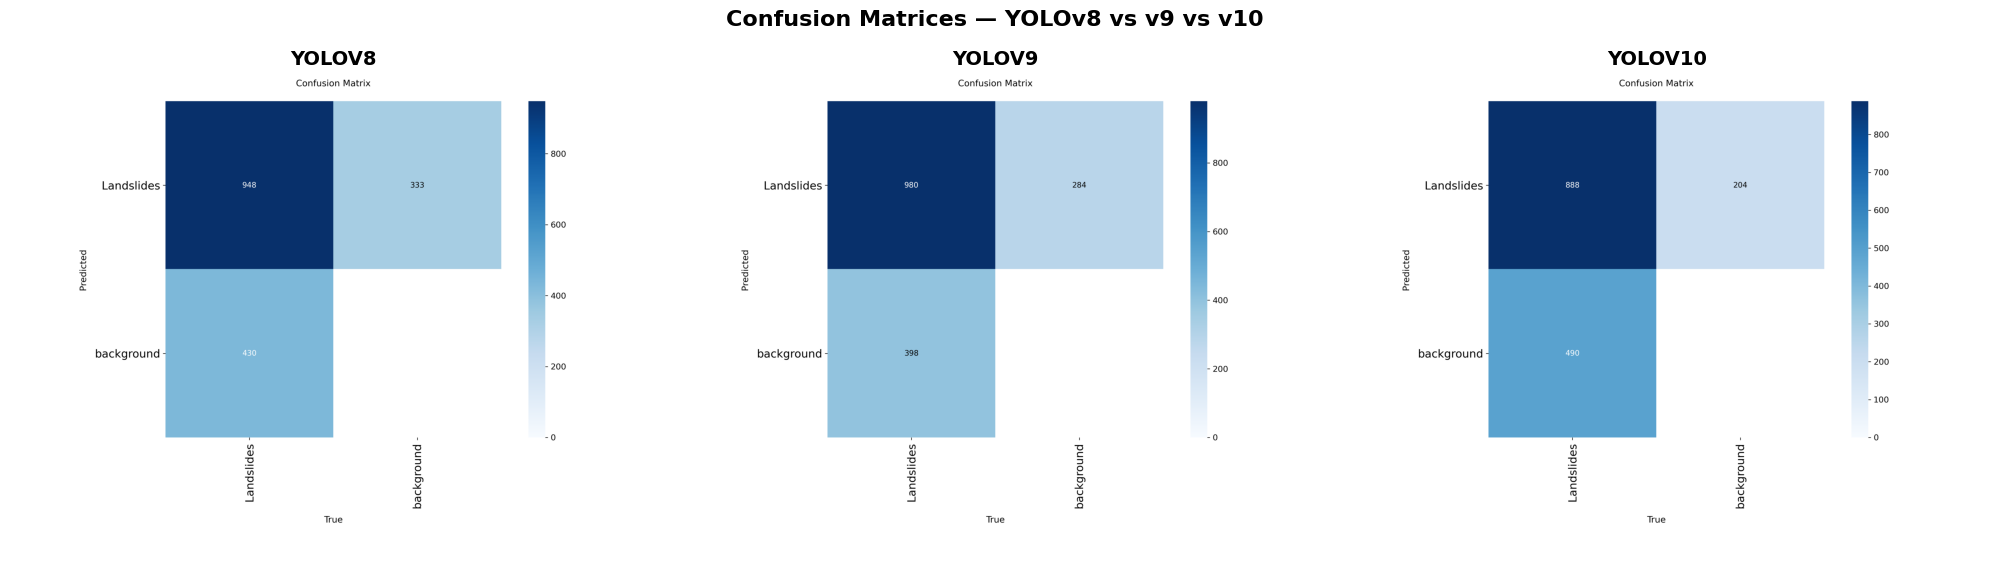

✅ Saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices — YOLOv8 vs v9 vs v10', fontsize=16, fontweight='bold')

for ax, model in zip(axes, models):
    found = False
    for cm_name in ['confusion_matrix_normalized.png', 'confusion_matrix.png']:
        cm_path = f"{BASE_PATH}/{model}/{cm_name}"
        if os.path.exists(cm_path):
            img = Image.open(cm_path)
            ax.imshow(img)
            ax.set_title(model.upper(), fontsize=14, fontweight='bold')
            ax.axis('off')
            found = True
            break
    if not found:
        ax.text(0.5, 0.5, 'Not Found', ha='center', va='center', color='red', fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

**PR Curves & F1 Curves Side by Side**

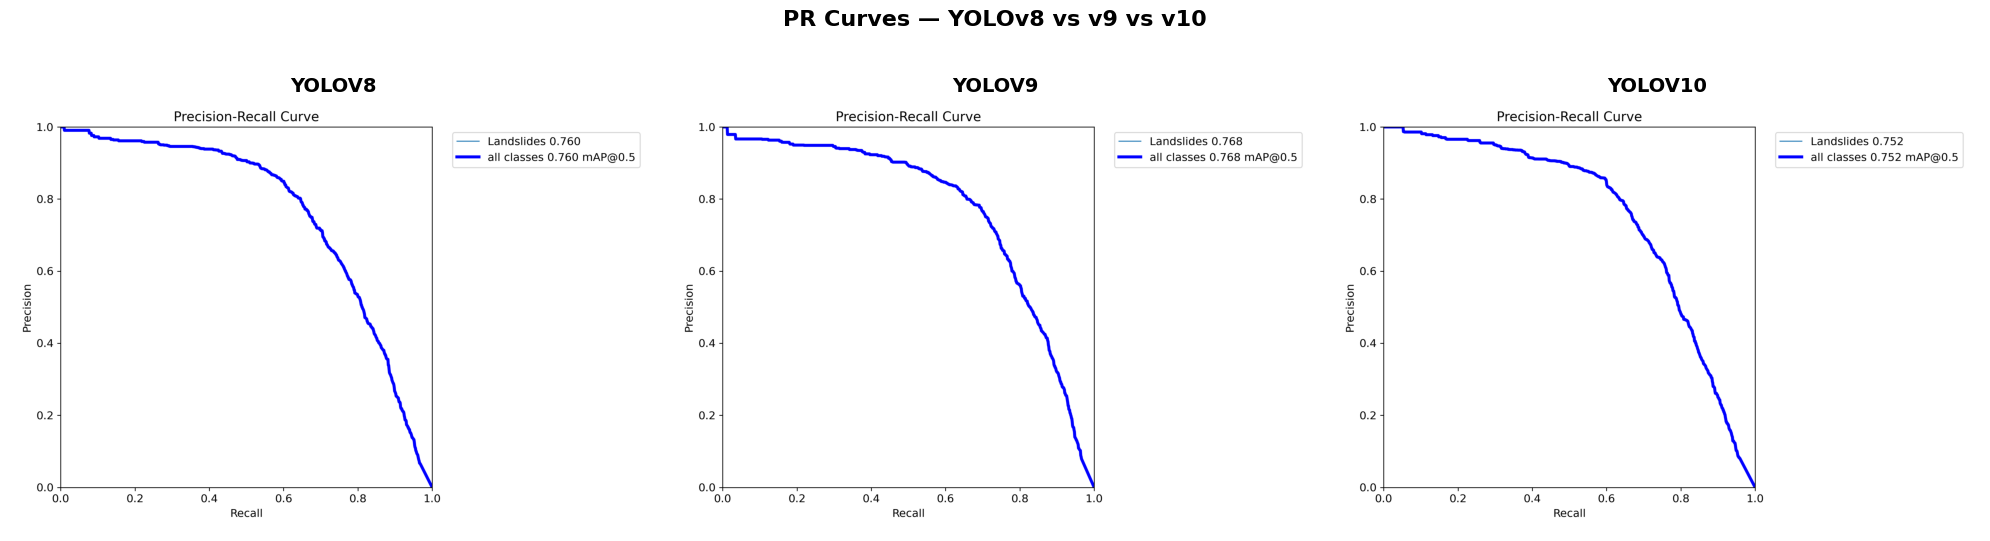

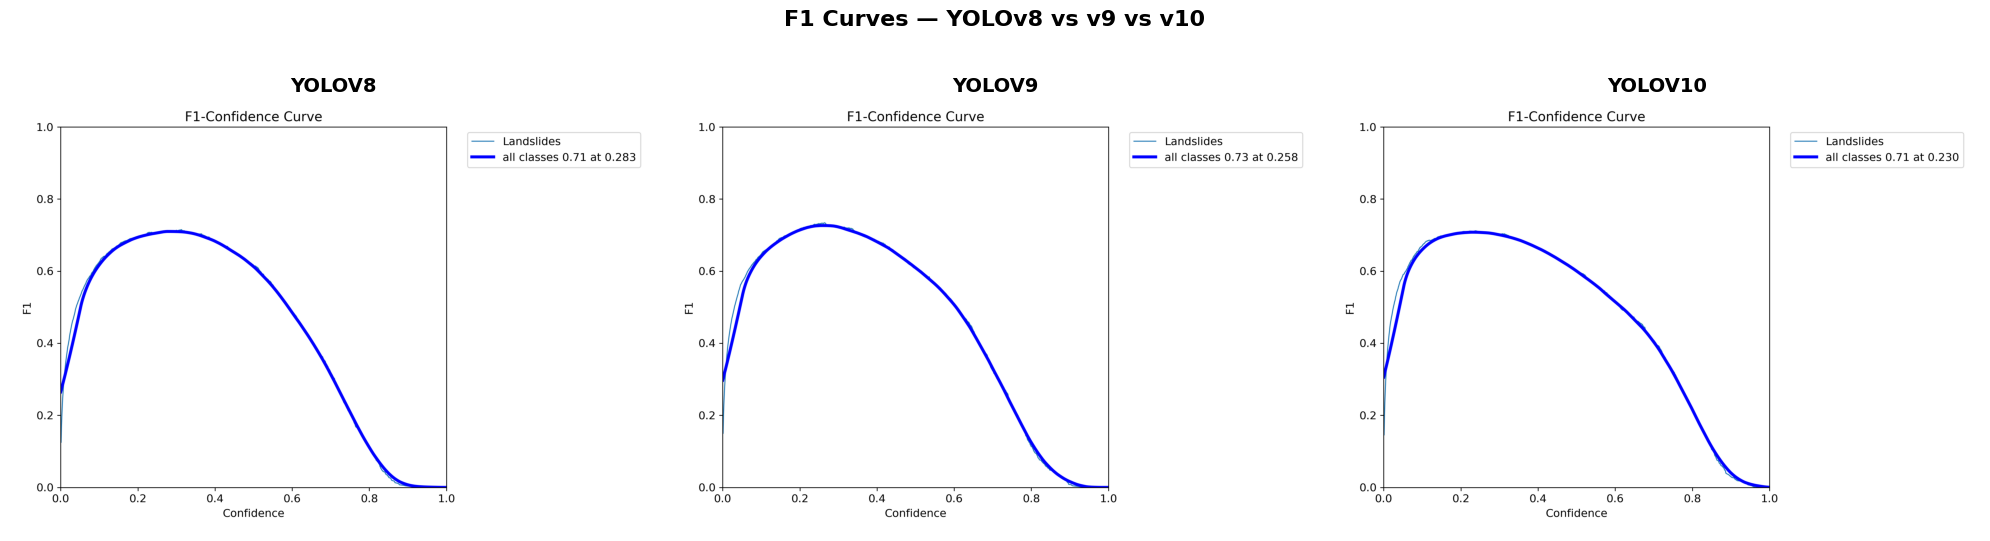

✅ Saved!


In [ ]:
# PR Curves
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('PR Curves — YOLOv8 vs v9 vs v10', fontsize=16, fontweight='bold')

for ax, model in zip(axes, models):
    pr_path = f"{BASE_PATH}/{model}/BoxPR_curve.png"
    if os.path.exists(pr_path):
        ax.imshow(Image.open(pr_path))
        ax.set_title(model.upper(), fontsize=14, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Not Found', ha='center', va='center', color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/4_PR_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# F1 Curves
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('F1 Curves — YOLOv8 vs v9 vs v10', fontsize=16, fontweight='bold')

for ax, model in zip(axes, models):
    f1_path = f"{BASE_PATH}/{model}/BoxF1_curve.png"
    if os.path.exists(f1_path):
        ax.imshow(Image.open(f1_path))
        ax.set_title(model.upper(), fontsize=14, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Not Found', ha='center', va='center', color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/5_F1_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

**Final Winner & Summary**

In [ ]:
print("=" * 60)
print("    🏆 FINAL COMPARISON — LANDSLIDE DETECTION")
print("=" * 60)
print(metrics_df[['mAP50','mAP50_95','Precision','Recall','F1']].to_string())
print("=" * 60)

for metric in ['mAP50', 'mAP50_95', 'Precision', 'Recall', 'F1']:
    best = metrics_df[metric].idxmax()
    val  = metrics_df[metric].max()
    print(f"🥇 Best {metric:12s} → {best.upper():10s} ({val:.4f})")

print("=" * 60)
ranked = metrics_df[['mAP50','mAP50_95','Precision','Recall','F1']].rank(ascending=False)
ranked['total'] = ranked.sum(axis=1)
winner = ranked['total'].idxmin()
print(f"\n🏆 OVERALL BEST MODEL : {winner.upper()}")
print("=" * 60)

metrics_df.to_csv(f'{BASE_PATH}/final_comparison.csv')
print("✅ final_comparison.csv saved!")

    🏆 FINAL COMPARISON — LANDSLIDE DETECTION
          mAP50  mAP50_95  Precision  Recall      F1
yolov8   0.7597    0.4390     0.7318  0.6814  0.7057
yolov9   0.7683    0.4549     0.7770  0.6929  0.7325
yolov10  0.7438    0.4372     0.7602  0.6480  0.6996
🥇 Best mAP50        → YOLOV9     (0.7683)
🥇 Best mAP50_95     → YOLOV9     (0.4549)
🥇 Best Precision    → YOLOV9     (0.7770)
🥇 Best Recall       → YOLOV9     (0.6929)
🥇 Best F1           → YOLOV9     (0.7325)

🏆 OVERALL BEST MODEL : YOLOV9
✅ final_comparison.csv saved!
